# Quiz: Semántica vectorial clásica — TF-IDF y ley de cosenos

**Maestría Virtual en Ingeniería de Sistemas y Computación · PLN · ACT_6**

Analizamos la similitud entre cuatro obras de Shakespeare representadas por vectores de
frecuencia de los términos **(battle, good, fool, wit)**, usando:

1. Matriz **TF-IDF** con normalización **L2**.
2. **Similitud coseno** con TF-IDF → obra más parecida a *Henry V*.
3. **Similitud coseno** con frecuencias **crudas** → obra más parecida a *Henry V*.
4. Comparación TF-IDF vs. crudas y respuesta a las preguntas del quiz.
5. Reducción de dimensionalidad (**PCA**) y visualización en el plano.

> Los datos son la clásica matriz término-documento de Jurafsky & Martin (SLP3, cap. Vector Semantics).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

## Datos

Cada obra es un vector de frecuencias de los términos `battle, good, fool, wit`.

| término | As You Like It | Twelfth Night | Julius Caesar | Henry V |
|---|---|---|---|---|
| battle | 1 | 0 | 7 | 13 |
| good | 114 | 80 | 62 | 89 |
| fool | 36 | 58 | 1 | 4 |
| wit | 20 | 15 | 2 | 3 |

In [2]:
terms = ['battle', 'good', 'fool', 'wit']
obras = ['As You Like It', 'Twelfth Night', 'Julius Caesar', 'Henry V']

# Filas = obras (documentos), columnas = términos
counts = np.array([
    [ 1, 114, 36, 20],   # As You Like It
    [ 0,  80, 58, 15],   # Twelfth Night
    [ 7,  62,  1,  2],   # Julius Caesar
    [13,  89,  4,  3],   # Henry V
], dtype=float)

df_counts = pd.DataFrame(counts, index=obras, columns=terms)
print('Frecuencias crudas (matriz término-documento):')
df_counts

Frecuencias crudas (matriz término-documento):


,battle,good,fool,wit
As You Like It,1.0000,114.0000,36.0000,20.0000
Twelfth Night,0.0000,80.0000,58.0000,15.0000
Julius Caesar,7.0000,62.0000,1.0000,2.0000
Henry V,13.0000,89.0000,4.0000,3.0000


## Punto 1 — Matriz TF-IDF + normalización L2

- **TF**: frecuencia del término en el documento.
- **IDF**: `log((1+N)/(1+df)) + 1` (fórmula de scikit-learn con `smooth_idf=True`), penaliza términos que aparecen en muchos documentos.
- **L2**: cada vector-documento se normaliza a norma 1 para que la comparación no dependa de la longitud del texto.

In [3]:
tfidf = TfidfTransformer(norm='l2', smooth_idf=True, sublinear_tf=False)
X_tfidf = tfidf.fit_transform(counts).toarray()

print('IDF por término (peso inverso de documento):')
for t, v in zip(terms, tfidf.idf_):
    print(f'  {t:7s}: {v:.4f}')

print('\nMatriz TF-IDF con normalización L2:')
df_tfidf = pd.DataFrame(X_tfidf, index=obras, columns=terms)
df_tfidf

IDF por término (peso inverso de documento):
  battle : 1.2231
  good   : 1.0000
  fool   : 1.0000
  wit    : 1.0000

Matriz TF-IDF con normalización L2:


,battle,good,fool,wit
As You Like It,0.0101,0.9405,0.2970,0.1650
Twelfth Night,0.0000,0.8004,0.5803,0.1501
Julius Caesar,0.1367,0.9900,0.0160,0.0319
Henry V,0.1756,0.9829,0.0442,0.0331


Se observa que `good`, `fool` y `wit` aparecen en las cuatro obras → su IDF es el mínimo
(1.0), mientras que `battle` (ausente en *Twelfth Night*) recibe un IDF mayor (≈1.22): es el
único término con algo de poder discriminativo en este corpus de 4 documentos.

## Punto 2 — Similitud coseno con TF-IDF (obra más parecida a *Henry V*)

In [4]:
S_tfidf = cosine_similarity(X_tfidf)
df_S_tfidf = pd.DataFrame(S_tfidf, index=obras, columns=obras)
print('Matriz de similitud coseno (TF-IDF):')
df_S_tfidf

Matriz de similitud coseno (TF-IDF):


,As You Like It,Twelfth Night,Julius Caesar,Henry V
As You Like It,1.0000,0.9499,0.9424,0.9448
Twelfth Night,0.9499,1.0000,0.8065,0.8174
Julius Caesar,0.9424,0.8065,1.0000,0.9988
Henry V,0.9448,0.8174,0.9988,1.0000


In [5]:
hv = obras.index('Henry V')
ranking_tfidf = sorted(
    [(obras[j], S_tfidf[hv, j]) for j in range(len(obras)) if j != hv],
    key=lambda x: -x[1]
)
print('Ranking de similitud con Henry V (TF-IDF):')
for nombre, sim in ranking_tfidf:
    print(f'  {nombre:16s}: {sim:.4f}')
print(f'\n>> Más parecida a Henry V (TF-IDF): {ranking_tfidf[0][0]} ({ranking_tfidf[0][1]:.4f})')

Ranking de similitud con Henry V (TF-IDF):
  Julius Caesar   : 0.9988
  As You Like It  : 0.9448
  Twelfth Night   : 0.8174

>> Más parecida a Henry V (TF-IDF): Julius Caesar (0.9988)


## Punto 3 — Similitud coseno con frecuencias crudas (obra más parecida a *Henry V*)

In [6]:
S_raw = cosine_similarity(counts)
df_S_raw = pd.DataFrame(S_raw, index=obras, columns=obras)
print('Matriz de similitud coseno (frecuencias crudas):')
df_S_raw

Matriz de similitud coseno (frecuencias crudas):


,As You Like It,Twelfth Night,Julius Caesar,Henry V
As You Like It,1.0000,0.9499,0.9449,0.9490
Twelfth Night,0.9499,1.0000,0.8090,0.8216
Julius Caesar,0.9449,0.8090,1.0000,0.9991
Henry V,0.9490,0.8216,0.9991,1.0000


In [7]:
ranking_raw = sorted(
    [(obras[j], S_raw[hv, j]) for j in range(len(obras)) if j != hv],
    key=lambda x: -x[1]
)
print('Ranking de similitud con Henry V (crudas):')
for nombre, sim in ranking_raw:
    print(f'  {nombre:16s}: {sim:.4f}')
print(f'\n>> Más parecida a Henry V (crudas): {ranking_raw[0][0]} ({ranking_raw[0][1]:.4f})')
print(f'   Henry V  vs  Julius Caesar = {S_raw[hv, obras.index("Julius Caesar")]:.4f}  (≈ 0.999)')

Ranking de similitud con Henry V (crudas):
  Julius Caesar   : 0.9991
  As You Like It  : 0.9490
  Twelfth Night   : 0.8216

>> Más parecida a Henry V (crudas): Julius Caesar (0.9991)
   Henry V  vs  Julius Caesar = 0.9991  (≈ 0.999)


## Punto 4 — Comparación y análisis

Comparemos lado a lado la similitud de *Henry V* con las demás obras bajo ambas representaciones.

In [8]:
comp = pd.DataFrame({
    'Coseno (crudas)': [S_raw[hv, j] for j in range(len(obras)) if j != hv],
    'Coseno (TF-IDF)': [S_tfidf[hv, j] for j in range(len(obras)) if j != hv],
}, index=[obras[j] for j in range(len(obras)) if j != hv])
comp['Diferencia'] = comp['Coseno (crudas)'] - comp['Coseno (TF-IDF)']
print('Similitud de Henry V con cada obra:')
comp

Similitud de Henry V con cada obra:


,Coseno (crudas),Coseno (TF-IDF),Diferencia
As You Like It,0.9490,0.9448,0.0043
Twelfth Night,0.8216,0.8174,0.0042
Julius Caesar,0.9991,0.9988,0.0002


### Respuestas

**¿Qué corrige la técnica de TF-IDF y qué es lo que penaliza?**

TF-IDF corrige el sesgo de las **frecuencias crudas hacia los términos muy comunes**.
El factor **IDF penaliza los términos que aparecen en muchos documentos** (alta *document
frequency*), porque un término presente en todas las obras —como `good`— casi no aporta
información para **distinguir** una obra de otra. Al multiplicar TF·IDF y normalizar (L2),
se **realza el peso de los términos discriminativos y raros** (aquí `battle`) y se **atenúa
el de los ubicuos** (`good`, `fool`, `wit`, con IDF mínimo).

**¿Con las frecuencias crudas, qué hace que Henry V ≈ Julius Caesar ≈ 0.999?**

Porque la similitud coseno cruda queda **dominada por la dimensión `good`**, que es con
diferencia la componente más grande en ambos vectores (Henry V = 89, Julius Caesar = 62).
El coseno mide el ángulo entre vectores; cuando una sola dimensión concentra casi toda la
magnitud, los dos vectores apuntan prácticamente en la misma dirección (la del eje `good`)
y las diferencias en `battle`, `fool` y `wit` quedan **ahogadas**. Resultado: un coseno de
≈0.999 aunque las obras no sean tan parecidas en los términos que sí las caracterizan.

**Nota sobre este corpus:** con solo 4 documentos y términos que aparecen en casi todos,
los IDF quedan casi uniformes, así que TF-IDF apenas cambia el *ranking* (Julius Caesar
sigue siendo la más parecida). El efecto de la corrección se ve en que la similitud
Henry V–Julius Caesar **baja** ligeramente (0.9991 → 0.9988) al descontar el peso del
término común `good`. En corpus grandes, donde los IDF varían mucho, esta corrección es
determinante.

## Punto 5 — Reducción de dimensionalidad (PCA) y visualización

Proyectamos las obras de 4 dimensiones a 2 con **PCA**, para las dos representaciones.

> *t-SNE* se deja como opcional: con solo 4 puntos no es informativo (requiere
> `perplexity < n_muestras`), por lo que PCA —lineal y determinista— es la opción adecuada aquí.

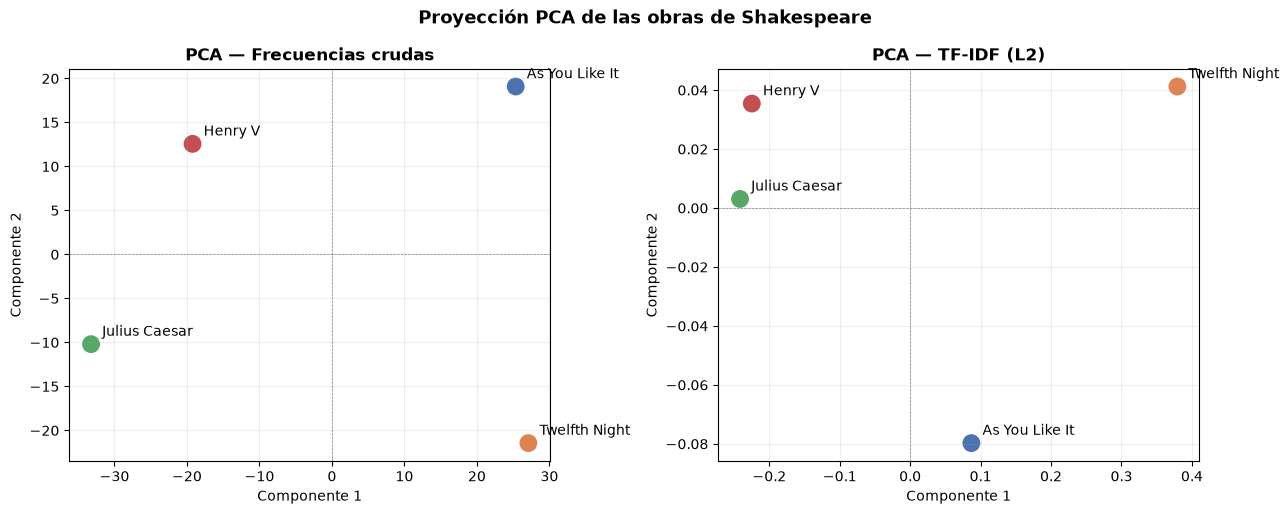

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for ax, (X, titulo) in zip(
    axes,
    [(counts, 'Frecuencias crudas'), (X_tfidf, 'TF-IDF (L2)')]
):
    coords = PCA(n_components=2, random_state=0).fit_transform(X)
    ax.scatter(coords[:, 0], coords[:, 1], s=140, c=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
    for (x, y), nombre in zip(coords, obras):
        ax.annotate(nombre, (x, y), textcoords='offset points', xytext=(8, 6), fontsize=10)
    ax.set_title(f'PCA — {titulo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.axhline(0, color='gray', lw=.5, ls='--'); ax.axvline(0, color='gray', lw=.5, ls='--')
    ax.grid(alpha=.2)

plt.suptitle('Proyección PCA de las obras de Shakespeare', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Lectura de las gráficas

- **Frecuencias crudas:** las obras dominadas por `good` (Julius Caesar y Henry V) quedan
  muy cerca, confirmando el coseno ≈0.999; la separación real entre obras se pierde.
- **TF-IDF:** al descontar los términos ubicuos, las obras se **despliegan mejor** en el
  plano y las diferencias temáticas (comedias con mucho `fool`/`wit` vs. historias con
  `battle`) se hacen más visibles.

## Conclusiones

- **TF-IDF** re-pondera la matriz término-documento penalizando términos frecuentes en
  todos los documentos y realzando los discriminativos; la **normalización L2** vuelve
  comparables obras de distinta longitud.
- La **similitud coseno con frecuencias crudas** es engañosa cuando un término común domina
  la magnitud (caso Henry V ≈ Julius Caesar ≈ 0.999).
- **PCA** confirma visualmente que la representación TF-IDF separa mejor los documentos que
  las frecuencias crudas.